In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
from scipy.stats import norm
from scipy.optimize import minimize
import os

/Users/stephensefa/anaconda3/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:430: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/stephensefa/anaconda3/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:430: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/stephensefa/anaconda3/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:420: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


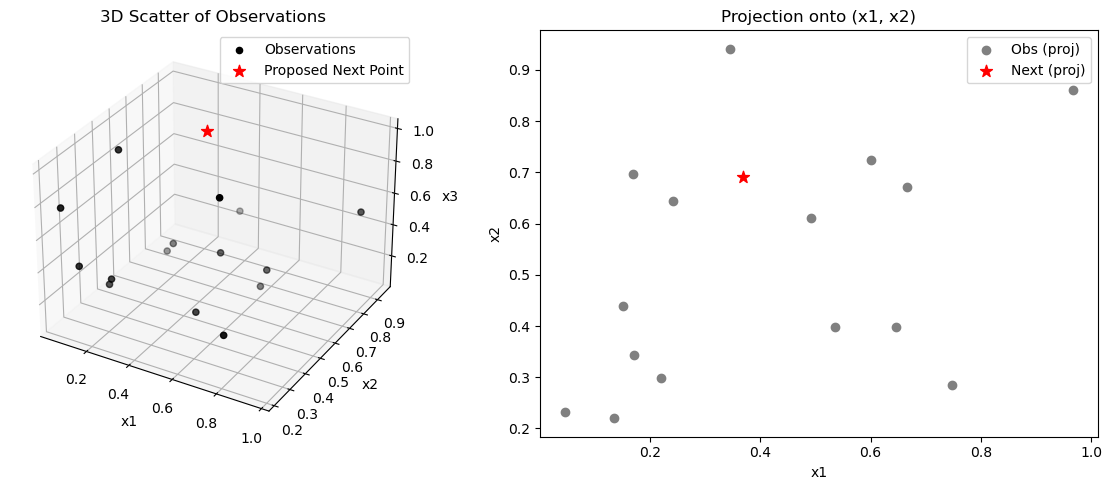

Suggested next point: [0.36961824 0.6902393  0.98394858]
Saved to: suggested_next_point.npy
Best observed y: -0.3989255131463011


In [2]:
# ---- Load data ----
INPUT_PATH = "initial_inputs.npy"
OUTPUT_PATH = "initial_outputs.npy"
SAVE_SUGGEST = "suggested_next_point.npy"

if not (os.path.exists(INPUT_PATH) and os.path.exists(OUTPUT_PATH)):
    raise FileNotFoundError("Place initial_inputs.npy and initial_outputs.npy in the working directory")

X = np.load(INPUT_PATH)
y = np.load(OUTPUT_PATH)

# Ensure shape: (N, 3)
if X.ndim == 1:
    X = X.reshape(-1, 1)
elif X.ndim == 2 and X.shape[1] != 3:
    raise ValueError("Expected a 3D input dataset of shape (N,3). Got shape {}".format(X.shape))
else:
    X = X.reshape(-1, 3)

y = y.reshape(-1)
d = 3  # fixed dimension

# ---- GP Model ----
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=np.ones(d), length_scale_bounds=(1e-2, 1e2)) \
         + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-8, 1e1))

gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=5)
gp.fit(X, y)

# ---- Bounds ----
mins = X.min(axis=0)
maxs = X.max(axis=0)
margin = 1e-6
bounds = [(float(mins[i] - margin), float(maxs[i] + margin)) for i in range(d)]

# ---- Expected Improvement ----
def expected_improvement(x, gp, y_best, xi=1e-3):
    x = np.asarray(x).reshape(1, -1)
    mu, sigma = gp.predict(x, return_std=True)
    mu = mu[0]
    sigma = sigma[0]
    if sigma <= 0:
        return 0.0
    imp = y_best - mu - xi  # minimisation
    Z = imp / sigma
    return imp * norm.cdf(Z) + sigma * norm.pdf(Z)

# ---- Suggest next point ----
def propose_next_point(gp, bounds, y_best, n_grid=5000, n_restarts=10):
    lb = np.array([b[0] for b in bounds])
    ub = np.array([b[1] for b in bounds])

    # random candidate grid
    candidates = np.random.uniform(lb, ub, size=(n_grid, d))
    ei_values = np.array([expected_improvement(c, gp, y_best) for c in candidates])

    # best initial guess
    x0 = candidates[np.argmax(ei_values)]

    def neg_ei(x):
        return -expected_improvement(x, gp, y_best)

    best = x0
    best_val = -neg_ei(x0)

    # local searches
    for _ in range(n_restarts):
        x_init = np.random.uniform(lb, ub)
        res = minimize(neg_ei, x_init, bounds=bounds, method='L-BFGS-B')
        if res.success and -res.fun > best_val:
            best = res.x
            best_val = -res.fun

    return best

y_best = np.min(y)
x_next = propose_next_point(gp, bounds, y_best)

# ---- Save result ----
np.save(SAVE_SUGGEST, x_next)

# ---- Plotting (3D projections) ----
fig = plt.figure(figsize=(12,5))

ax = fig.add_subplot(121, projection='3d')
ax.scatter(X[:,0], X[:,1], X[:,2], c='k', label='Observations')
ax.scatter(x_next[0], x_next[1], x_next[2], c='red', s=80, marker='*', label='Proposed Next Point')
ax.set_title("3D Scatter of Observations")
ax.set_xlabel("x1"); ax.set_ylabel("x2"); ax.set_zlabel("x3")
ax.legend()

ax2 = fig.add_subplot(122)
ax2.scatter(X[:,0], X[:,1], c='gray', label='Obs (proj)')
ax2.scatter(x_next[0], x_next[1], c='red', s=80, marker='*', label='Next (proj)')
ax2.set_title("Projection onto (x1, x2)")
ax2.set_xlabel("x1"); ax2.set_ylabel("x2")
ax2.legend()

plt.tight_layout()
plt.show()

# ---- Print results ----
print("Suggested next point:", x_next)
print("Saved to:", SAVE_SUGGEST)
print("Best observed y:", y_best)
